# **SQL–Amazon India Sales Dataset Analysis** / ***SQL-Menganalisa Amazon India Sales Dataset***

## **Introduction**/ ***Pendahuluan***

The Amazon Sales Dataset consists e-commerce prices and product reviews listed on Amazon India. The dataset includes prices, discounts and ratings for these products. The Dataset have 1,465 rows and 16 columns, they are:

Kumpulan Amazon Sales Dataset ini terdiri dari harga e-commerce dan ulasan produk yang terdaftar di Amazon India. Kumpulan data ini menampilkan harga, diskon dan ulasan penilaain untuk produk-produk tersebut. Data ini memiliki 1465 baris dan 16 kolom  diantaranya: 

1.	Product_id
2.	product_name
3.	category
4.	discounted_price
5.	actual_price
6.	discount_percentage
7.	rating
8.	rating_count
9.	about_product
10.	user_id 
11.	user_name
12.	review_id
13.	review_title
14.	review_content
15.	img_link
16.	product_link 

## **Objectives** / ***Tujuan***
### **1. Data Cleaning:**
    • Data Type & Schema Audit / Audit Tipe Data & Skema
    • Distinct Value Count per Column / Jumlah Nilai Unik per Kolom
    • Null Count & Null Percentage per Column / Jumlah Nilai Null & Persentase Nilai Null per Kolom
    • Top 10 Most Frequent Values per Column / 10 Nilai Teratas yang Paling Sering Muncul per Kolom
    • Data Type Conversion and Cleaning / Konversi dan Pembersihan Tipe Data

### **2. Analytics:**
    • Revenue by Multi-Dimension
    • Median dan Percentile

### **3. Modeling**

## **SQL -ANALYSIS**

In [60]:
import duckdb
import pandas as pd
import numpy as np
cursor = duckdb.connect()
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
import os
from PIL import Image
import io
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print (cursor.execute('SELECT 42').fetchall())

[(42,)]


In [2]:
db_amazon = pd.read_csv ('amazon.csv')

In [9]:
duckdb.sql ("CREATE TABLE amazons AS SELECT * FROM db_amazon")

In [3]:
db_amazon.head ()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


### Data Cleaning

#### Data Type & Schema Audit / Audit Tipe Data & Skema

In [11]:
q_data_type = """
SELECT
    column_name,
    data_type,
    is_nullable,
    NULL AS is_partitioning_column,
    NULL AS clustering_oridinal_position
FROM INFORMATION_SCHEMA.COLUMNS WHERE table_name = 'amazons'
"""
dtyp = duckdb.sql (q_data_type ).df()
dtyp

,column_name,data_type,is_nullable,is_partitioning_column,clustering_oridinal_position
0,product_id,VARCHAR,YES,<NA>,<NA>
1,product_name,VARCHAR,YES,<NA>,<NA>
2,category,VARCHAR,YES,<NA>,<NA>
3,discounted_price,VARCHAR,YES,<NA>,<NA>
4,actual_price,VARCHAR,YES,<NA>,<NA>
5,discount_percentage,VARCHAR,YES,<NA>,<NA>
6,rating,VARCHAR,YES,<NA>,<NA>
7,rating_count,VARCHAR,YES,<NA>,<NA>
8,about_product,VARCHAR,YES,<NA>,<NA>
9,user_id,VARCHAR,YES,<NA>,<NA>


#### Distinct Value Count per Column / Jumlah Nilai Unik per Kolom

In [13]:
q_dv = """
SELECT 
    COUNT (*) AS total_rows,
    COUNT (DISTINCT product_id) AS dis_product_id,
    COUNT (DISTINCT product_name) AS dis_product_name,
    COUNT (DISTINCT category) AS dis_category,
    COUNT (DISTINCT discounted_price) AS dis_discount,
    COUNT (DISTINCT actual_price) AS dis_actual_price,
    COUNT (DISTINCT discount_percentage) AS dis_disc_persentase,
    COUNT (DISTINCT rating) AS dis_rating
FROM amazons

"""

ddv = duckdb.sql (q_dv).df()
ddv

,total_rows,dis_product_id,dis_product_name,dis_category,dis_discount,dis_actual_price,dis_disc_persentase,dis_rating
0,1465,1351,1337,211,550,449,92,28


#### Null Count & Null Percentage per Column / Jumlah Nilai Null & Persentase Nilai Null per Kolom

In [45]:
q_prnull = """
SELECT  
    COUNT (*) AS total_rows,
    ROUND (COUNTIF (product_id IS NULL) / COUNT (*) *100,2) AS pct_null_product_id,
    ROUND (COUNTIF (product_name IS NULL) / COUNT (*) *100,2) AS pct_null_produk_name,
    ROUND (COUNTIF (category IS NULL) / COUNT (*) * 100, 2) AS pct_null_category,
    ROUND (COUNTIF (discounted_price IS NULL) / COUNT (*) * 100, 2) AS pct_null_discprice,
    ROUND (COUNTIF (actual_price IS NULL) / COUNT (*) *100,2) AS pct_null_price,
    ROUND (COUNTIF (discount_percentage IS NULL) / COUNT (*) * 100, 2) AS pct_null_discpersen,
    ROUND (COUNTIF (rating IS NULL) / COUNT (*) * 100, 2) AS pct_null_rating
FROM amazons

"""
dprnull = duckdb.sql(q_prnull).df()
dprnull

,total_rows,pct_null_product_id,pct_null_produk_name,pct_null_category,pct_null_discprice,pct_null_price,pct_null_discpersen,pct_null_rating
0,1465,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Top 10 Most Frequent Values per Column / 10 Nilai Teratas yang Paling Sering Muncul per Kolom

In [15]:
q_mfreq= """
WITH 
id_freq AS (
    SELECT 
        product_id as value,
        COUNT(*) as frequency,
        ROUND (SUM (COUNT (*)) OVER (ORDER BY COUNT (*) DESC) / SUM (COUNT(*)) OVER () *100,2) AS cumulative_pct,
        ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) as rank,
        ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 2) as pct
    FROM amazons
    WHERE product_id IS NOT NULL
    GROUP BY product_id
    LIMIT 10
),
name_freq AS (
    SELECT 
        product_name as value,
        COUNT(*) as frequency,
        ROUND (SUM (COUNT (*)) OVER (ORDER BY COUNT (*) DESC) / SUM (COUNT(*)) OVER () *100,2) AS cumulative_pct,
        ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) as rank,
        ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 2) as pct
    FROM amazons
    WHERE product_name IS NOT NULL
    GROUP BY product_name
    LIMIT 10
)
SELECT 
    COALESCE(i.rank, n.rank) as rank,
    i.value as product_id,
    i.frequency as id_frequency,
    i.pct as id_percentage,
    i.cumulative_pct as cumulative_pct,
    n.value as product_name,
    n.frequency as name_frequency,
    n.pct as name_percentage,
    n.cumulative_pct as cumulative_pct
FROM id_freq i
FULL OUTER JOIN name_freq n ON i.rank = n.rank
ORDER BY rank
"""

dmf = duckdb.sql(q_mfreq).df()
dmf

,rank,product_id,id_frequency,id_percentage,cumulative_pct,product_name,name_frequency,name_percentage,cumulative_pct_1
0,1,B09W5XR9RT,3,0.2,4.51,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5,0.34,0.34
1,2,B09C6HXFC1,3,0.2,4.51,Fire-Boltt Phoenix Smart Watch with Bluetooth ...,4,0.27,0.61
2,3,B08WRWPM22,3,0.2,4.51,Flix Micro Usb Cable For Smartphone (Black),3,0.20,5.73
3,4,B07JW9H4J1,3,0.2,4.51,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",3,0.20,5.73
4,5,B098NS6PVG,3,0.2,4.51,Portronics Konnect L 1.2M POR-1401 Fast Chargi...,3,0.20,5.73
5,6,B08CF3D7QR,3,0.2,4.51,Duracell USB Lightning Apple Certified (Mfi) B...,3,0.20,5.73
6,7,B085DTN6R2,3,0.2,4.51,"Samsung Galaxy M13 5G (Aqua Green, 6GB, 128GB ...",3,0.20,5.73
7,8,B07XLCFSSN,3,0.2,4.51,MI Usb Type-C Cable Smartphone (Black),3,0.20,5.73
8,9,B096MSW6CT,3,0.2,4.51,boAt A400 USB Type-C to USB-A 2.0 Male Data Ca...,3,0.20,5.73
9,10,B09CMP1SC8,3,0.2,4.51,Wayona Nylon Braided USB to Lightning Fast Cha...,3,0.20,5.73


### ANALYTICS

#### Revenue by Multi-Dimension

In [21]:
q_sales ="""
WITH db_cleaning AS (
SELECT
    product_id,
    product_name,
    REPLACE(REPLACE(discounted_price, '₹', ''), ',', '')::DECIMAL AS clean_disc_price,
    REPLACE(REPLACE(actual_price, '₹', ''), ',', '')::DECIMAL AS clean_actual_price,
    discount_percentage
FROM amazons
ORDER BY product_id ASC
) 
SELECT
    product_name,
    COUNT (product_name) AS count_sales,
    ROUND (SUM (clean_actual_price),0) AS total_sales,
    ROUND (SUM (clean_disc_price),0) AS total_net_sales,
    ROUND ( SUM (clean_actual_price) - SUM (clean_disc_price),0) AS total_disc_sales,
    ROUND (AVG (clean_disc_price),0) AS avg_net_sales
FROM db_cleaning
GROUP BY product_name
ORDER BY total_net_sales DESC
LIMIT 10


"""

d_sales = duckdb.sql(q_sales).df()
d_sales

,product_name,count_sales,total_sales,total_net_sales,total_disc_sales,avg_net_sales
0,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,1,139900.0,77990.0,61910.0,77990.0
1,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,1,69999.0,61999.0,8000.0,61999.0
2,VU 164 cm (65 inches) The GloLED Series 4K Sma...,1,85000.0,54990.0,30010.0,54990.0
3,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,1,79990.0,47990.0,32000.0,47990.0
4,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,1,70900.0,47990.0,22910.0,47990.0
5,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,1,69999.0,46999.0,23000.0,46999.0
6,Samsung 138 cm (55 inches) Crystal 4K Series U...,1,69900.0,45999.0,23901.0,45999.0
7,"OnePlus 10T 5G (Moonstone Black, 8GB RAM, 128G...",1,49999.0,44999.0,5000.0,44999.0
8,OnePlus 138.7 cm (55 inches) U Series 4K LED S...,1,59999.0,42999.0,17000.0,42999.0
9,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,1,75990.0,42990.0,33000.0,42990.0


##### Median dan Percentile

In [23]:
q_median_percen ="""
WITH dbmp_clean AS (
SELECT
    product_id,
    product_name,
    REPLACE(REPLACE(discounted_price, '₹', ''), ',', '')::DECIMAL AS clean_disc_price,
    REPLACE(REPLACE(actual_price, '₹', ''), ',', '')::DECIMAL AS clean_actual_price,
    discount_percentage
FROM amazons
ORDER BY product_id ASC
) 
SELECT
    COUNT (*) AS count_sales,
    ROUND (AVG (clean_disc_price),0) AS avg_sales,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY clean_disc_price) AS P25_net_revenue,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY clean_disc_price) AS P50_net_revenue,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY clean_disc_price) AS P75_net_revenue,
    PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY clean_disc_price) AS P90_net_revenue,
    PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY clean_disc_price) AS P99_net_revenue,
    MIN (clean_disc_price) AS min_net_revenue,
    MAX (clean_disc_price) AS max_net_revenue
    
FROM dbmp_clean

"""

d_mp = duckdb.sql(q_median_percen).df()
d_mp

,count_sales,avg_sales,P25_net_revenue,P50_net_revenue,P75_net_revenue,P90_net_revenue,P99_net_revenue,min_net_revenue,max_net_revenue
0,1465,3125.0,325.0,799.0,1999.0,8499.0,34358.999,39.0,77990.0


In [25]:
print("📊 DATA OVERVIEW")
print("="*50)
print(f"Total unique products: {len(d_sales)}")
print(f"Total sales value: ₹ {d_sales['total_sales'].sum():,.0f}")
print(f"Total net sales: ₹ {d_sales['total_net_sales'].sum():,.0f}")
print(f"Total discount given: ₹ {d_sales['total_disc_sales'].sum():,.0f}")
print(f"Average discount rate: {(d_sales['total_disc_sales'].sum()/d_sales['total_sales'].sum()*100):.1f}%")
print(f"Top product: {d_sales.iloc[0]['product_name'][:50]}... (₹ {d_sales.iloc[0]['total_net_sales']:,.0f})")

📊 DATA OVERVIEW
Total unique products: 10
Total sales value: ₹ 771,676
Total net sales: ₹ 514,945
Total discount given: ₹ 256,731
Average discount rate: 33.3%
Top product: Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart L... (₹ 77,990)


### MODELING


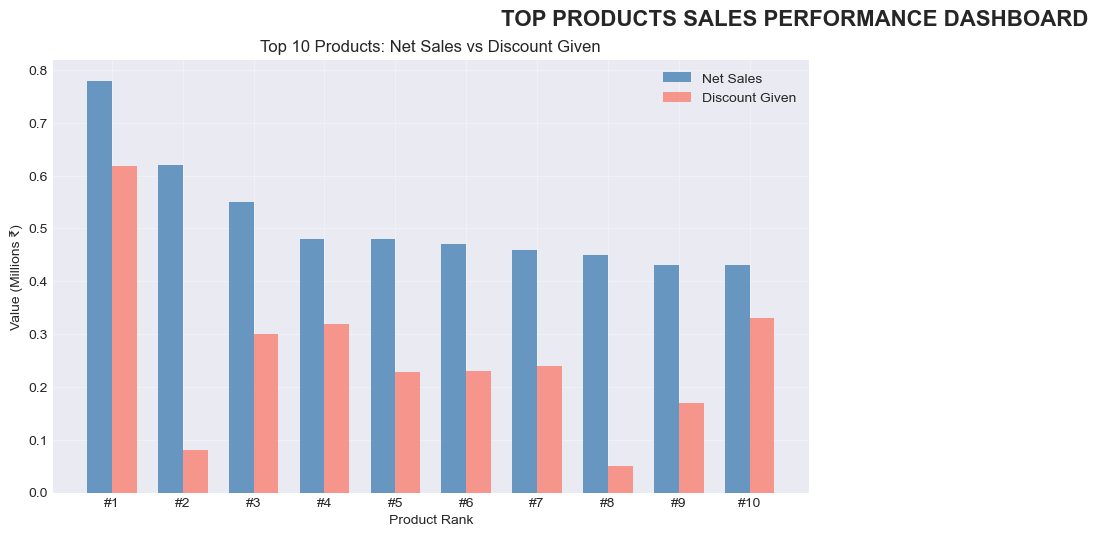

In [27]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('TOP PRODUCTS SALES PERFORMANCE DASHBOARD', fontsize=16, fontweight='bold')

# Top 10 products by net sales
top_10 = d_sales.head(10)

# 1. Bar chart - Net Sales vs Discount
ax1 = plt.subplot(2, 2, 1)
x = range(len(top_10))
width = 0.35
ax1.bar([i - width/2 for i in x], top_10['total_net_sales']/1e5, width, 
        label='Net Sales', color='steelblue', alpha=0.8)
ax1.bar([i + width/2 for i in x], top_10['total_disc_sales']/1e5, width, 
        label='Discount Given', color='salmon', alpha=0.8)
ax1.set_xlabel('Product Rank')
ax1.set_ylabel('Value (Millions ₹)')
ax1.set_title('Top 10 Products: Net Sales vs Discount Given')
ax1.set_xticks(x)
ax1.set_xticklabels([f'#{i+1}' for i in x])
ax1.legend()
ax1.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

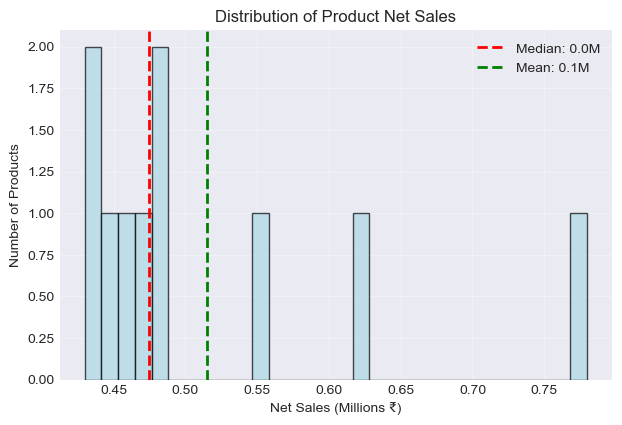

In [29]:
# 2. Sales distribution histogram
ax2 = plt.subplot(2, 2, 3)
ax2.hist(d_sales['total_net_sales']/1e5, bins=30, edgecolor='black', 
         color='lightblue', alpha=0.7)
ax2.axvline(d_sales['total_net_sales'].median()/1e5, color='red', 
            linestyle='--', linewidth=2, label=f'Median: {d_sales["total_net_sales"].median()/1e6:.1f}M')
ax2.axvline(d_sales['total_net_sales'].mean()/1e5, color='green', 
            linestyle='--', linewidth=2, label=f'Mean: {d_sales["total_net_sales"].mean()/1e6:.1f}M')
ax2.set_xlabel('Net Sales (Millions ₹)')
ax2.set_ylabel('Number of Products')
ax2.set_title('Distribution of Product Net Sales')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### SUMMARY

 SUMMARY DATA OVERVIEW

------------------------------------------------------------
DATA TYPE & SCHEMA AUDIT SUMMARY
------------------------------------------------------------
   All 16 coloumns  VARCHAR
   → Need Conversion type

📌  CONVERSION RECOMMENDATION:
   discounted_price     → DECIMAL/FLOAT
   actual_price         → DECIMAL/FLOAT
   discount_percentage  → FLOAT
   rating               → FLOAT
   rating_count         → DECIMAL/FLOAT


------------------------------------------------------------
DATA UNIQUENESS HORIZONTAL BAR CHART
------------------------------------------------------------
product_id:     ██████████████████████████████████████████████      92.2% (1,351)
product_name:   █████████████████████████████████████████████       91.3% (1,337)
category:       ███████                                             14.4% (211)
discount_pct:   ███                                                  6.3% (92)
rating:                                                             

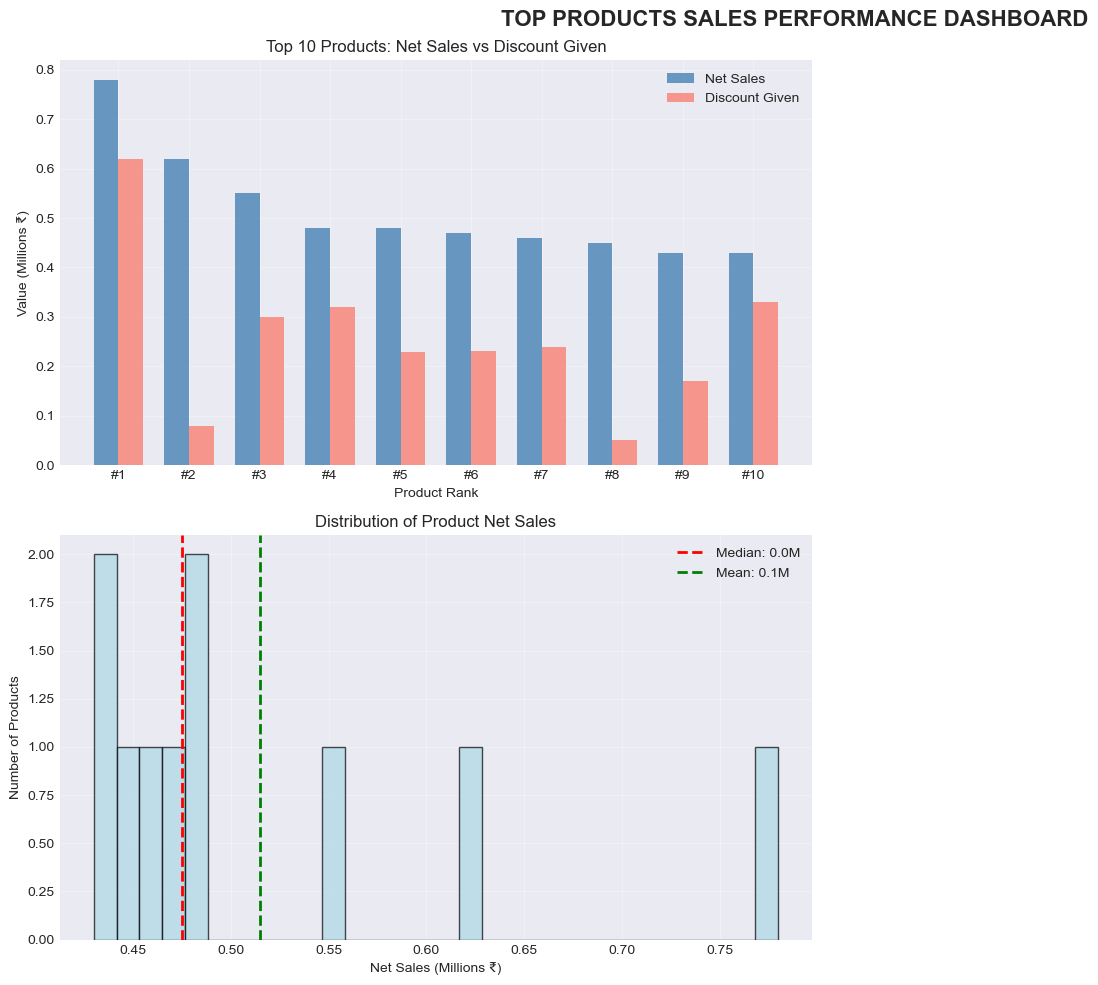


 Bar chart displayed above


In [55]:
print(" SUMMARY DATA OVERVIEW")
print("="*60)

# stastic Count /Hitung statistik 
total_columns = len(dtyp)
varchar_columns = dtyp[dtyp['data_type'] == 'VARCHAR']['column_name'].tolist()
numeric_candidates = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

# Short summary / Ringkasan sederhana
print("\n" + "-" * 60)
print("DATA TYPE & SCHEMA AUDIT SUMMARY")
print("-" * 60)

print(f"   All {total_columns} coloumns  VARCHAR")
print(f"   → Need Conversion type")

print(f"\n📌  CONVERSION RECOMMENDATION:")
for col in numeric_candidates:
    if col in varchar_columns:
        if col in ['discount_percentage', 'rating']:
            print(f"   {col:<20} → FLOAT")
        else:
            print(f"   {col:<20} → DECIMAL/FLOAT")


print("\n" + "=" * 60)

print("\n" + "-" * 60)
print("DATA UNIQUENESS HORIZONTAL BAR CHART")
print("-" * 60)

# Source / Ambil nilai
total = ddv['total_rows'].iloc[0]
prod_id = ddv['dis_product_id'].iloc[0]
prod_name = ddv['dis_product_name'].iloc[0]
category = ddv['dis_category'].iloc[0]
discount = ddv['dis_disc_persentase'].iloc[0]
rating = ddv['dis_rating'].iloc[0]

# horizontal bar chart

# product_id
pct = (prod_id / total) * 100
bar = "█" * int(pct / 2)
print(f"product_id:     {bar:<50} {pct:>5.1f}% ({prod_id:,})")

# product_name
pct = (prod_name / total) * 100
bar = "█" * int(pct / 2)
print(f"product_name:   {bar:<50} {pct:>5.1f}% ({prod_name:,})")

# category
pct = (category / total) * 100
bar = "█" * int(pct / 2)
print(f"category:       {bar:<50} {pct:>5.1f}% ({category:,})")

# discount_percentage
pct = (discount / total) * 100
bar = "█" * int(pct / 2)
print(f"discount_pct:   {bar:<50} {pct:>5.1f}% ({discount:,})")

# rating
pct = (rating / total) * 100
bar = "█" * int(pct / 2)
print(f"rating:         {bar:<50} {pct:>5.1f}% ({rating:,})")

print("-" * 60)
print(f"Total rows: {total:,}")
print("-" * 60)

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total Rows          : {ddv['total_rows'][0]:,}")
print(f"Unique Product IDs  : {ddv['dis_product_id'][0]:,}")
print(f"Unique Product Names: {ddv['dis_product_name'][0]:,}")
print(f"Unique Categories   : {ddv['dis_category'][0]:,}")
print(f"Unique Ratings      : {ddv['dis_rating'][0]:,}")

print("\n" + "="*60)
dprnull_transposed = dprnull.T
dprnull_transposed.column = ['value']
dprnull_transposed.index.name = 'Metric'

print ("\n" + "-"* 60)
print ("NULL COUNT & PERCENTAGE ANALYSIS")
print ("-"*60)
print (dprnull_transposed.to_string())

print("\n" + "="*60)

print("\n" + "-"*60)
print("TOP 10 PRODUCTS BY NET SALES")
print("-"*60)
print(f"{'Rank':<6} {'Product Name':<45} {'Net Sales':>18}")
print("-"*80)


# Accumulation Variabel /Variabel untuk akumulasi
total_net_top10 = 0

# Looping top 10 / Looping untuk menampilkan top 10
for idx, row in d_sales.iterrows():
    rank = idx + 1
    product_name = row['product_name']
    net_sales = row['total_net_sales']

    # Accumulation / Akumulasi
    total_net_top10 += net_sales 
    
    # Short cut product_naame / Potong product_name jika terlalu panjang
    if len(product_name) > 42:
        product_name = product_name[:39] + "..."
    
    # Print Line / Cetak baris
    print(f"{rank:<6} {product_name:<45} ₹ {net_sales:>15,.0f}")

print("-"*60)
print(f"{'Total Top 10':<51} ₹ {total_net_top10:>15,.0f}")
print("-"*60)

print("DATA OVERVIEW")
print("-"*60)
print(f"Total unique products: {len(d_sales)}")
print(f"Total sales value: ₹ {d_sales['total_sales'].sum():,.0f}")
print(f"Total net sales: ₹ {d_sales['total_net_sales'].sum():,.0f}")
print(f"Total discount given: ₹ {d_sales['total_disc_sales'].sum():,.0f}")
print(f"Average discount rate: {(d_sales['total_disc_sales'].sum()/d_sales['total_sales'].sum()*100):.1f}%")
print(f"Top product: {d_sales.iloc[0]['product_name'][:50]}... (₹ {d_sales.iloc[0]['total_net_sales']:,.0f})")

print("="*60)

print("\n" + "-"*60)
print("GENERATING BAR CHART TOP 10 PRODUCTS BY NET SALES")
print("-"*60)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('TOP PRODUCTS SALES PERFORMANCE DASHBOARD', fontsize=16, fontweight='bold')

# Top 10 products by net sales
top_10 = d_sales.head(10)

# 1. Bar chart - Net Sales vs Discount
ax1 = plt.subplot(2, 2, 1)
x = range(len(top_10))
width = 0.35
ax1.bar([i - width/2 for i in x], top_10['total_net_sales']/1e5, width, 
        label='Net Sales', color='steelblue', alpha=0.8)
ax1.bar([i + width/2 for i in x], top_10['total_disc_sales']/1e5, width, 
        label='Discount Given', color='salmon', alpha=0.8)
ax1.set_xlabel('Product Rank')
ax1.set_ylabel('Value (Millions ₹)')
ax1.set_title('Top 10 Products: Net Sales vs Discount Given')
ax1.set_xticks(x)
ax1.set_xticklabels([f'#{i+1}' for i in x])
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Sales distribution histogram
ax2 = plt.subplot(2, 2, 3)
ax2.hist(d_sales['total_net_sales']/1e5, bins=30, edgecolor='black', 
         color='lightblue', alpha=0.7)
ax2.axvline(d_sales['total_net_sales'].median()/1e5, color='red', 
            linestyle='--', linewidth=2, label=f'Median: {d_sales["total_net_sales"].median()/1e6:.1f}M')
ax2.axvline(d_sales['total_net_sales'].mean()/1e5, color='green', 
            linestyle='--', linewidth=2, label=f'Mean: {d_sales["total_net_sales"].mean()/1e6:.1f}M')
ax2.set_xlabel('Net Sales (Millions ₹)')
ax2.set_ylabel('Number of Products')
ax2.set_title('Distribution of Product Net Sales')
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("\n Bar chart displayed above")

In [62]:
# ============================================
# 1. SAVING FOLDER/ FOLDER UNTUK MENYIMPAN
# ============================================
export_dir = "export_images"
os.makedirs(export_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
images_dir = f"{export_dir}/images_{timestamp}"
os.makedirs(images_dir, exist_ok=True)

print("="*60)
print("STARTING EXPORT TO JPG/PNG")
print("="*60)

# ============================================
# 2. FUNGSI UNTUK CAPTURE PRINT OUTPUT KE GAMBAR
# ============================================

def capture_text_to_image(text_lines, title, filename, dpi=150):
    """
    Mengubah teks print menjadi gambar PNG/JPG
    
    Parameters:
    - text_lines: list of strings (baris-baris teks)
    - title: judul gambar
    - filename: nama file output
    - dpi: resolusi gambar
    """
    # Hitung tinggi gambar berdasarkan jumlah baris
    line_height = 0.05  # Tinggi per baris dalam koordinat relatif
    fig_height = max(8, len(text_lines) * 0.3)  # Tinggi minimal 8 inch
    
    fig, ax = plt.subplots(figsize=(11, fig_height))
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Gabungkan semua teks
    text_content = "\n".join(text_lines)
    
    # Tampilkan teks di figure
    ax.text(0.05, 0.95, text_content, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Tambahkan timestamp
    ax.text(0.05, 0.02, f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", 
            transform=ax.transAxes, fontsize=8, color='gray')
    
    plt.tight_layout()
    
    # Simpan sebagai PNG
    png_path = os.path.join(images_dir, f"{filename}.png")
    plt.savefig(png_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    
    # Konversi ke JPG
    jpg_path = os.path.join(images_dir, f"{filename}.jpg")
    img = Image.open(png_path)
    img.convert('RGB').save(jpg_path, 'JPEG', quality=95)
    
    plt.close()
    print(f"  ✅ Saved: {filename}.png / {filename}.jpg")
    return png_path, jpg_path

# ============================================
# 3. CAPTURE DATA TYPE & SCHEMA AUDIT
# ============================================
print("Capturing DATA TYPE & SCHEMA AUDIT...")

text_lines_type = []
text_lines_type.append("=" * 60)
text_lines_type.append("SUMMARY DATA OVERVIEW")
text_lines_type.append("=" * 60)
text_lines_type.append("")
text_lines_type.append("-" * 60)
text_lines_type.append("DATA TYPE & SCHEMA AUDIT SUMMARY")
text_lines_type.append("-" * 60)

total_columns = len(dtyp)
text_lines_type.append(f"   All {total_columns} columns are VARCHAR")
text_lines_type.append("   → Need Conversion type")
text_lines_type.append("")
text_lines_type.append("📌 CONVERSION RECOMMENDATION:")

varchar_columns = dtyp[dtyp['data_type'] == 'VARCHAR']['column_name'].tolist()
numeric_candidates = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

for col in numeric_candidates:
    if col in varchar_columns:
        if col in ['discount_percentage', 'rating']:
            text_lines_type.append(f"   {col:<20} → FLOAT")
        else:
            text_lines_type.append(f"   {col:<20} → DECIMAL/FLOAT")

text_lines_type.append("")
text_lines_type.append("=" * 60)

capture_text_to_image(text_lines_type, "DATA TYPE & SCHEMA AUDIT", "01_data_type_audit", dpi=150)

# ============================================
# 4. CAPTURE DATA UNIQUENESS HORIZONTAL BAR CHART
# ============================================
print("Capturing DATA UNIQUENESS...")

text_lines_uniqueness = []
text_lines_uniqueness.append("-" * 60)
text_lines_uniqueness.append("DATA UNIQUENESS HORIZONTAL BAR CHART")
text_lines_uniqueness.append("-" * 60)

# Source data
total = ddv['total_rows'].iloc[0]
prod_id = ddv['dis_product_id'].iloc[0]
prod_name = ddv['dis_product_name'].iloc[0]
category = ddv['dis_category'].iloc[0]
discount = ddv['dis_disc_persentase'].iloc[0]
rating = ddv['dis_rating'].iloc[0]

# Function to create bar string
def create_bar(pct, max_width=50):
    bar_length = int(pct / 2)
    return "█" * bar_length + "░" * (max_width - bar_length)

# product_id
pct = (prod_id / total) * 100
bar = create_bar(pct)
text_lines_uniqueness.append(f"product_id:     {bar} {pct:>5.1f}% ({prod_id:,})")

# product_name
pct = (prod_name / total) * 100
bar = create_bar(pct)
text_lines_uniqueness.append(f"product_name:   {bar} {pct:>5.1f}% ({prod_name:,})")

# category
pct = (category / total) * 100
bar = create_bar(pct)
text_lines_uniqueness.append(f"category:       {bar} {pct:>5.1f}% ({category:,})")

# discount_percentage
pct = (discount / total) * 100
bar = create_bar(pct)
text_lines_uniqueness.append(f"discount_pct:   {bar} {pct:>5.1f}% ({discount:,})")

# rating
pct = (rating / total) * 100
bar = create_bar(pct)
text_lines_uniqueness.append(f"rating:         {bar} {pct:>5.1f}% ({rating:,})")

text_lines_uniqueness.append("-" * 60)
text_lines_uniqueness.append(f"Total rows: {total:,}")
text_lines_uniqueness.append("-" * 60)

capture_text_to_image(text_lines_uniqueness, "DATA UNIQUENESS ANALYSIS", "02_data_uniqueness", dpi=150)

# ============================================
# 5. CAPTURE DATASET SUMMARY
# ============================================
print("Capturing DATASET SUMMARY...")

text_lines_summary = []
text_lines_summary.append("=" * 60)
text_lines_summary.append("DATASET SUMMARY")
text_lines_summary.append("=" * 60)
text_lines_summary.append(f"Total Rows          : {ddv['total_rows'][0]:,}")
text_lines_summary.append(f"Unique Product IDs  : {ddv['dis_product_id'][0]:,}")
text_lines_summary.append(f"Unique Product Names: {ddv['dis_product_name'][0]:,}")
text_lines_summary.append(f"Unique Categories   : {ddv['dis_category'][0]:,}")
text_lines_summary.append(f"Unique Ratings      : {ddv['dis_rating'][0]:,}")
text_lines_summary.append("")
text_lines_summary.append("=" * 60)

capture_text_to_image(text_lines_summary, "DATASET SUMMARY", "03_dataset_summary", dpi=150)

# ============================================
# 6. CAPTURE NULL COUNT & PERCENTAGE ANALYSIS
# ============================================
print("Capturing NULL COUNT & PERCENTAGE ANALYSIS...")

# Fix transpose
dprnull_transposed = dprnull.T
dprnull_transposed.columns = ['Value']  # Perbaikan: .columns bukan .column
dprnull_transposed.index.name = 'Metric'

text_lines_null = []
text_lines_null.append("-" * 60)
text_lines_null.append("NULL COUNT & PERCENTAGE ANALYSIS")
text_lines_null.append("-" * 60)

for idx, row in dprnull_transposed.iterrows():
    if idx == 'total_rows':
        text_lines_null.append(f"{idx:<30}: {row['Value']:,.0f}")
    else:
        text_lines_null.append(f"{idx:<30}: {row['Value']:.2f}%")

text_lines_null.append("")
text_lines_null.append("=" * 60)

capture_text_to_image(text_lines_null, "NULL COUNT & PERCENTAGE ANALYSIS", "04_null_analysis", dpi=150)

# ============================================
# 7. CAPTURE TOP 10 PRODUCTS
# ============================================
print("Capturing TOP 10 PRODUCTS...")

text_lines_top10 = []
text_lines_top10.append("-" * 60)
text_lines_top10.append("TOP 10 PRODUCTS BY NET SALES")
text_lines_top10.append("-" * 60)
text_lines_top10.append(f"{'Rank':<6} {'Product Name':<45} {'Net Sales':>18}")
text_lines_top10.append("-" * 80)

total_net_top10 = 0
for idx, row in d_sales.iterrows():
    rank = idx + 1
    product_name = row['product_name']
    net_sales = row['total_net_sales']
    total_net_top10 += net_sales
    
    if len(product_name) > 42:
        product_name = product_name[:39] + "..."
    
    text_lines_top10.append(f"{rank:<6} {product_name:<45} ₹ {net_sales:>15,.0f}")

text_lines_top10.append("-" * 60)
text_lines_top10.append(f"{'Total Top 10':<51} ₹ {total_net_top10:>15,.0f}")
text_lines_top10.append("-" * 60)

capture_text_to_image(text_lines_top10, "TOP 10 PRODUCTS BY NET SALES", "05_top10_products", dpi=150)

# ============================================
# 8. CAPTURE DATA OVERVIEW
# ============================================
print("Capturing DATA OVERVIEW...")

text_lines_overview = []
text_lines_overview.append("=" * 60)
text_lines_overview.append("DATA OVERVIEW")
text_lines_overview.append("-" * 60)
text_lines_overview.append(f"Total unique products: {len(d_sales)}")
text_lines_overview.append(f"Total sales value: ₹ {d_sales['total_sales'].sum():,.0f}")
text_lines_overview.append(f"Total net sales: ₹ {d_sales['total_net_sales'].sum():,.0f}")
text_lines_overview.append(f"Total discount given: ₹ {d_sales['total_disc_sales'].sum():,.0f}")
text_lines_overview.append(f"Average discount rate: {(d_sales['total_disc_sales'].sum()/d_sales['total_sales'].sum()*100):.1f}%")
text_lines_overview.append(f"Top product: {d_sales.iloc[0]['product_name'][:50]}...")
text_lines_overview.append(f"Top product revenue: ₹ {d_sales.iloc[0]['total_net_sales']:,.0f}")
text_lines_overview.append("=" * 60)

capture_text_to_image(text_lines_overview, "DATA OVERVIEW SUMMARY", "06_data_overview", dpi=150)

# ============================================
# 9. CAPTURE BAR CHART (SEBAGAI GAMBAR)
# ============================================
print("Capturing BAR CHART...")

fig_bar = plt.figure(figsize=(14, 8))
top_10 = d_sales.head(10)
x = range(len(top_10))
width = 0.35

plt.bar([i - width/2 for i in x], top_10['total_net_sales']/1e5, width, 
        label='Net Sales', color='steelblue', alpha=0.8)
plt.bar([i + width/2 for i in x], top_10['total_disc_sales']/1e5, width, 
        label='Discount Given', color='salmon', alpha=0.8)

plt.xlabel('Product Rank', fontsize=12)
plt.ylabel('Value (Lakhs ₹)', fontsize=12)
plt.title('Top 10 Products: Net Sales vs Discount Given', fontsize=14, fontweight='bold')
plt.xticks(x, [f'#{i+1}' for i in x])
plt.legend()
plt.grid(True, alpha=0.3)

# Simpan sebagai PNG
bar_png = os.path.join(images_dir, "07_bar_chart.png")
plt.savefig(bar_png, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig_bar)

# Konversi ke JPG
bar_jpg = os.path.join(images_dir, "07_bar_chart.jpg")
img = Image.open(bar_png)
img.convert('RGB').save(bar_jpg, 'JPEG', quality=95)
print(f"  ✅ Saved: bar_chart.png / bar_chart.jpg")

# ============================================
# 10. CAPTURE HISTOGRAM
# ============================================
print("Capturing HISTOGRAM...")

fig_hist = plt.figure(figsize=(14, 8))
plt.hist(d_sales['total_net_sales']/1e5, bins=30, edgecolor='black', 
         color='lightblue', alpha=0.7)

median_val = d_sales['total_net_sales'].median()
mean_val = d_sales['total_net_sales'].mean()

plt.axvline(median_val/1e5, color='red', linestyle='--', linewidth=2, 
            label=f'Median: {median_val/1e6:.1f}M')
plt.axvline(mean_val/1e5, color='green', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_val/1e6:.1f}M')

plt.xlabel('Net Sales (Lakhs ₹)', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.title('Distribution of Product Net Sales', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Simpan sebagai PNG
hist_png = os.path.join(images_dir, "08_histogram.png")
plt.savefig(hist_png, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig_hist)

# Konversi ke JPG
hist_jpg = os.path.join(images_dir, "08_histogram.jpg")
img = Image.open(hist_png)
img.convert('RGB').save(hist_jpg, 'JPEG', quality=95)
print(f"  ✅ Saved: histogram.png / histogram.jpg")

# ============================================
# 11. BUAT DASHBOARD GABUNGAN (SEMUA CHART DALAM 1 GAMBAR)
# ============================================
print("Creating combined dashboard...")

fig_combined, axes = plt.subplots(2, 2, figsize=(16, 12))
fig_combined.suptitle('AMAZON PRODUCTS SALES DASHBOARD', fontsize=16, fontweight='bold')

# Subplot 1: Bar Chart
ax1 = axes[0, 0]
x = range(len(top_10))
width = 0.35
ax1.bar([i - width/2 for i in x], top_10['total_net_sales']/1e5, width, 
        label='Net Sales', color='steelblue', alpha=0.8)
ax1.bar([i + width/2 for i in x], top_10['total_disc_sales']/1e5, width, 
        label='Discount Given', color='salmon', alpha=0.8)
ax1.set_xlabel('Product Rank')
ax1.set_ylabel('Value (Lakhs ₹)')
ax1.set_title('Top 10 Products: Net Sales vs Discount')
ax1.set_xticks(x)
ax1.set_xticklabels([f'#{i+1}' for i in x])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Histogram
ax2 = axes[0, 1]
ax2.hist(d_sales['total_net_sales']/1e5, bins=30, edgecolor='black', 
         color='lightblue', alpha=0.7)
ax2.axvline(median_val/1e5, color='red', linestyle='--', linewidth=2, 
            label=f'Median: {median_val/1e6:.1f}M')
ax2.axvline(mean_val/1e5, color='green', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_val/1e6:.1f}M')
ax2.set_xlabel('Net Sales (Lakhs ₹)')
ax2.set_ylabel('Number of Products')
ax2.set_title('Distribution of Net Sales')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Top 10 Products Table (text)
ax3 = axes[1, 0]
ax3.axis('off')
table_data = []
for i, row in d_sales.head(10).iterrows():
    name = row['product_name'][:30] + '...' if len(row['product_name']) > 33 else row['product_name']
    table_data.append([i+1, name, f"₹ {row['total_net_sales']/1e5:.0f}L"])
table = ax3.table(cellText=table_data, colLabels=['Rank', 'Product Name', 'Net Sales'],
                  loc='center', cellLoc='left', colWidths=[0.15, 0.6, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax3.set_title('Top 10 Products', fontsize=12, fontweight='bold')

# Subplot 4: Key Metrics
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = f"""
KEY METRICS
{'='*30}

Total Products: {len(d_sales):,}
Total Net Sales: ₹ {d_sales['total_net_sales'].sum()/1e6:.1f}M
Average Discount: {(d_sales['total_disc_sales'].sum()/d_sales['total_sales'].sum()*100):.1f}%
Top Product Share: {(d_sales.iloc[0]['total_net_sales']/d_sales['total_net_sales'].sum()*100):.1f}%
Data Completeness: {(1 - dprnull['pct_null_rating'].iloc[0]/100)*100:.1f}%
"""
ax4.text(0.1, 0.5, metrics_text, transform=ax4.transAxes, fontsize=12,
         verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax4.set_title('Performance Summary', fontsize=12, fontweight='bold')

plt.tight_layout()

# Simpan dashboard
dashboard_png = os.path.join(images_dir, "09_combined_dashboard.png")
plt.savefig(dashboard_png, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig_combined)

# Konversi ke JPG
dashboard_jpg = os.path.join(images_dir, "09_combined_dashboard.jpg")
img = Image.open(dashboard_png)
img.convert('RGB').save(dashboard_jpg, 'JPEG', quality=95)
print(f"  ✅ Saved: combined_dashboard.png / combined_dashboard.jpg")

# ============================================
# 12. SUMMARY EXPORT
# ============================================
print("\n" + "="*60)
print("EXPORT SUMMARY - JPG/PNG")
print("="*60)
print(f"\n Images saved to: {images_dir}")
print("\n LIST OF GENERATED IMAGES:")
print("-" * 50)

image_files = sorted(os.listdir(images_dir))
for img_file in image_files:
    file_path = os.path.join(images_dir, img_file)
    file_size = os.path.getsize(file_path) / 1024  # KB
    print(f"  • {img_file:<35} ({file_size:.1f} KB)")

print("-" * 50)
print(f"\n✅ Total images: {len(image_files)}")
print(f" Folder: {images_dir}")
print("\n EXPORT COMPLETED SUCCESSFULLY!")
print("="*60)

# Optional: Buka folder (Windows)
import subprocess
subprocess.Popen(f'explorer "{os.path.abspath(images_dir)}"')

STARTING EXPORT TO JPG/PNG
Capturing DATA TYPE & SCHEMA AUDIT...
  ✅ Saved: 01_data_type_audit.png / 01_data_type_audit.jpg
Capturing DATA UNIQUENESS...
  ✅ Saved: 02_data_uniqueness.png / 02_data_uniqueness.jpg
Capturing DATASET SUMMARY...
  ✅ Saved: 03_dataset_summary.png / 03_dataset_summary.jpg
Capturing NULL COUNT & PERCENTAGE ANALYSIS...
  ✅ Saved: 04_null_analysis.png / 04_null_analysis.jpg
Capturing TOP 10 PRODUCTS...
  ✅ Saved: 05_top10_products.png / 05_top10_products.jpg
Capturing DATA OVERVIEW...
  ✅ Saved: 06_data_overview.png / 06_data_overview.jpg
Capturing BAR CHART...
  ✅ Saved: bar_chart.png / bar_chart.jpg
Capturing HISTOGRAM...
  ✅ Saved: histogram.png / histogram.jpg
Creating combined dashboard...
  ✅ Saved: combined_dashboard.png / combined_dashboard.jpg

EXPORT SUMMARY - JPG/PNG

 Images saved to: export_images/images_20260528_111208

 LIST OF GENERATED IMAGES:
--------------------------------------------------
  • 01_data_type_audit.jpg              (126.6 KB)
 

<Popen: returncode: None args: 'explorer "D:\\01. Timur\\15. Project\\01. Am...>